# Assignment 1: Enterprise Knowledge Retrieval for Pharma & Healthcare Research

**Problem:** Build a hybrid multimodal retrieval system over healthcare documents.  
**Data:** PubMed abstracts (sampled) + NIH Chest X-ray images (sampled).  
**Phases:** Classical IR → Dense Retrieval → Re-ranking → Evaluation → Multimodal Extension

---


## Setup — Install Dependencies

In [1]:
# Run once. Restart kernel after if needed.
import subprocess, sys

packages = [
    "rank_bm25",
    "sentence-transformers",
    "nltk",
    "Pillow",
    "scikit-learn",
    "numpy",
    "transformers",
    "torch",
    "requests",
    "matplotlib",
    "pandas",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)
print("All packages ready.")


All packages ready.


## Imports & NLTK Data

In [2]:
import os, re, math, json, pickle, requests, warnings
from collections import defaultdict, Counter
from itertools import chain

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from rank_bm25 import BM25Okapi

from sentence_transformers import SentenceTransformer, CrossEncoder

warnings.filterwarnings("ignore")

for resource in ["punkt", "stopwords", "wordnet", "punkt_tab"]:
    nltk.download(resource, quiet=True)

STEMMER    = PorterStemmer()
LEMMATIZER = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words("english"))

print("Imports OK.")


/Users/sanketpanchalwar/miniforge3/envs/ds_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK.


---
## Dataset — PubMed Abstracts (Sampled)

We fetch a sample of PubMed abstracts via the NCBI E-utilities API (no API key needed for small batches).  
**Target:** ~200 abstracts covering oncology, immunotherapy, and drug interactions — matches the assignment queries.

For the full assignment run, replace `SEARCH_TERMS` or increase `MAX_DOCS`.


In [44]:
!pip3 install bs4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [bs4]


In [45]:
# ── Cell: Load PMC Open Access Full-Text XML Corpus ───────────────────────────
#
# Source: https://ftp.ncbi.nlm.nih.gov/pub/pmc/deprecated/oa_bulk/oa_comm/xml/
#
# Pipeline:
#   1. List all tar.gz files from the FTP index page
#   2. Download first N archives (each ~30-50MB, contains 100s of articles)
#   3. Extract XML files in-memory (no intermediate disk extraction needed)
#   4. Parse JATS XML → title, abstract, body per article
#   5. Build CORPUS list used by all downstream phases

import os, re, glob, tarfile, requests
from pathlib import Path
from xml.etree import ElementTree as ET
from bs4 import BeautifulSoup

# ── Config ────────────────────────────────────────────────────────────────────
FTP_INDEX_URL  = "https://ftp.ncbi.nlm.nih.gov/pub/pmc/deprecated/oa_bulk/oa_comm/xml/"
DATA_DIR       = Path("pmc_data")
N_ARCHIVES     = 3      # number of tar.gz files to download (each ~30-50MB)
MAX_DOCS       = 200    # cap total articles for a lightweight local run
DATA_DIR.mkdir(exist_ok=True)

# ── Step 1: Scrape FTP index to find all tar.gz file names ───────────────────
print("Fetching FTP index ...")
resp  = requests.get(FTP_INDEX_URL, timeout=30)
resp.raise_for_status()
soup  = BeautifulSoup(resp.text, "html.parser")

# Each <a href> ending in .tar.gz is one archive package
tar_gz_files = [
    a["href"] for a in soup.find_all("a", href=True)
    if a["href"].endswith(".tar.gz")
]
print(f"Found {len(tar_gz_files)} archives on FTP. Using first {N_ARCHIVES}.")
print("Sample:", tar_gz_files[:5])

# ── Step 2: Download archives (skip if already cached locally) ────────────────
def download_file(url, dest_path, chunk_size=256 * 1024):
    """Stream-download a file with a simple progress indicator."""
    with requests.get(url, stream=True, timeout=180) as r:
        r.raise_for_status()
        total     = int(r.headers.get("content-length", 0))
        received  = 0
        with open(dest_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                f.write(chunk)
                received += len(chunk)
                if total:
                    print(f"\r  {received/total*100:.1f}%", end="", flush=True)
    print()  # newline after progress

selected = tar_gz_files[:N_ARCHIVES]

for fname in selected:
    dest = DATA_DIR / fname
    if dest.exists():
        print(f"  Cached: {fname}")
        continue
    print(f"Downloading {fname} ...")
    download_file(FTP_INDEX_URL + fname, dest)
    print(f"  Saved → {dest}")

# ── Step 3 & 4: Extract XML in-memory and parse JATS format ──────────────────
#
# JATS (Journal Article Tag Suite) is the XML standard used by PMC.
# Key tags we care about:
#   <article-title>                  → paper title
#   <abstract><p>...</p></abstract>  → structured abstract
#   <body>                           → full text (we take first 500 words)
#   <article-id pub-id-type="pmid">  → PubMed ID
#   <article-id pub-id-type="pmc">   → PMC ID

def get_text(element):
    """Recursively collect all inner text from an XML element, stripped."""
    return " ".join(element.itertext()).strip()

def find_tag(root, tag):
    """Find first element matching tag, ignoring any XML namespace prefix."""
    for el in root.iter():
        if re.sub(r"\{.*?\}", "", el.tag) == tag:
            return el
    return None

def find_all_tags(root, tag):
    """Find all elements matching tag, ignoring any XML namespace prefix."""
    return [el for el in root.iter() if re.sub(r"\{.*?\}", "", el.tag) == tag]

def parse_jats_xml(xml_bytes):
    """
    Parse one PMC JATS XML article.
    Returns a dict or None if the article has no usable title/abstract.
    """
    try:
        root = ET.fromstring(xml_bytes)
    except ET.ParseError:
        return None

    # Title
    title_el = find_tag(root, "article-title")
    title    = get_text(title_el) if title_el is not None else ""

    # Abstract — join all <p> tags inside <abstract>
    abstract_el = find_tag(root, "abstract")
    if abstract_el is not None:
        paras    = find_all_tags(abstract_el, "p")
        abstract = " ".join(get_text(p) for p in paras) if paras else get_text(abstract_el)
    else:
        abstract = ""

    # Body — cap at first 500 words to keep memory usage reasonable
    body_el = find_tag(root, "body")
    body    = " ".join(get_text(body_el).split()[:500]) if body_el is not None else ""

    # Skip articles with nothing useful
    if not title and not abstract:
        return None

    # IDs
    pmc_id = pmid = ""
    for id_el in find_all_tags(root, "article-id"):
        id_type = id_el.attrib.get("pub-id-type", "")
        if id_type == "pmc":
            pmc_id = id_el.text or ""
        elif id_type == "pmid":
            pmid = id_el.text or ""

    return {
        "title"    : title,
        "abstract" : abstract,
        "body"     : body,
        "text"     : f"{title} {abstract} {body}".strip(),  # combined field used downstream
        "pmc_id"   : pmc_id,
        "pmid"     : pmid,
    }

# ── Step 5: Build corpus by reading directly from tar.gz (no disk extraction) ─
#
# tarfile.extractfile() gives us a file-like object for each member in memory,
# so we never need to write thousands of XML files to disk.

print(f"\nParsing articles from {N_ARCHIVES} archive(s) ...")
all_docs = []
skipped  = 0

for fname in selected:
    tar_path = DATA_DIR / fname
    print(f"  Reading {fname} ...")

    with tarfile.open(tar_path, "r:gz") as tar:
        xml_members = [m for m in tar.getmembers()
                       if m.name.endswith(".xml") or m.name.endswith(".nxml")]
        print(f"    XML files in archive: {len(xml_members)}")

        for member in xml_members:
            if len(all_docs) >= MAX_DOCS:
                break
            try:
                fobj     = tar.extractfile(member)
                doc      = parse_jats_xml(fobj.read()) if fobj else None
                if doc:
                    all_docs.append(doc)
                else:
                    skipped += 1
            except Exception:
                skipped += 1

    if len(all_docs) >= MAX_DOCS:
        break

# ── Final corpus ──────────────────────────────────────────────────────────────
CORPUS = all_docs
print(f"\nCorpus ready:")
print(f"  Articles parsed : {len(CORPUS)}")
print(f"  Skipped         : {skipped}")
print(f"\nSample document:")
print(f"  PMC ID   : {CORPUS[0]['pmc_id']}")
print(f"  Title    : {CORPUS[0]['title'][:80]}")
print(f"  Abstract : {CORPUS[0]['abstract'][:150]}...")

Fetching FTP index ...
Found 139 archives on FTP. Using first 3.
Sample: ['oa_comm_xml.PMC000xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC001xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC002xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC003xxxxxx.baseline.2026-01-23.tar.gz', 'oa_comm_xml.PMC004xxxxxx.baseline.2026-01-23.tar.gz']
  100.0%
  Saved → pmc_data/oa_comm_xml.PMC000xxxxxx.baseline.2026-01-23.tar.gz
  100.0%
  Saved → pmc_data/oa_comm_xml.PMC001xxxxxx.baseline.2026-01-23.tar.gz
  100.0%
  Saved → pmc_data/oa_comm_xml.PMC002xxxxxx.baseline.2026-01-23.tar.gz

Parsing articles from 3 archive(s) ...
  Reading oa_comm_xml.PMC000xxxxxx.baseline.2026-01-23.tar.gz ...
    XML files in archive: 3028

Corpus ready:
  Articles parsed : 200
  Skipped         : 0

Sample document:
  PMC ID   : PMC176545
  Title    : The Transcriptome of the Intraerythrocytic Developmental Cycle of  Plasmodium fa
  Abstract : Plasmodium falciparum  is the causative agent of the most burdens

---
## Phase 1: Classical Information Retrieval

### 1.1 — Text Preprocessing Pipeline


In [46]:
def preprocess(text, use_stemming=True):
    """
    Full preprocessing pipeline:
      tokenize → lowercase → remove non-alpha → remove stopwords → stem/lemmatize
    Returns list of tokens.
    """
    # Tokenize
    tokens = word_tokenize(text.lower())
    # Keep only alphabetic tokens
    tokens = [t for t in tokens if t.isalpha()]
    # Remove stopwords
    tokens = [t for t in tokens if t not in STOP_WORDS]
    # Stem or lemmatize
    if use_stemming:
        tokens = [STEMMER.stem(t) for t in tokens]
    else:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return tokens

# Preprocess the entire corpus
processed_corpus = [preprocess(doc["text"]) for doc in CORPUS]

# Demo
sample_text = "Lung cancer immunotherapy adverse effects in non-small-cell carcinoma patients"
print("Original  :", sample_text)
print("Processed :", preprocess(sample_text))


Original  : Lung cancer immunotherapy adverse effects in non-small-cell carcinoma patients
Processed : ['lung', 'cancer', 'immunotherapi', 'advers', 'effect', 'carcinoma', 'patient']


### 1.2 — Inverted Index

In [47]:
class InvertedIndex:
    """Maps each term → sorted list of doc IDs containing it."""

    def __init__(self):
        self.index    = defaultdict(set)   # term → {doc_ids}
        self.doc_freq = defaultdict(int)   # term → document frequency

    def build(self, tokenized_docs):
        for doc_id, tokens in enumerate(tokenized_docs):
            for term in set(tokens):       # set → count each term once per doc
                self.index[term].add(doc_id)
                self.doc_freq[term] += 1

    def get(self, term):
        return sorted(self.index.get(term, set()))

inv_index = InvertedIndex()
inv_index.build(processed_corpus)

print(f"Vocabulary size : {len(inv_index.index):,} unique terms")
sample_term = preprocess("immunotherapy")[0]
print(f"Docs containing '{sample_term}': {inv_index.get(sample_term)[:10]} ...")


Vocabulary size : 7,223 unique terms
Docs containing 'immunotherapi': [] ...


### 1.3 — Positional Index

In [48]:
class PositionalIndex:
    """
    Maps term → {doc_id: [positions]} — enables phrase queries.
    """

    def __init__(self):
        self.index = defaultdict(lambda: defaultdict(list))

    def build(self, tokenized_docs):
        for doc_id, tokens in enumerate(tokenized_docs):
            for pos, term in enumerate(tokens):
                self.index[term][doc_id].append(pos)

    def phrase_query(self, phrase_tokens):
        """Return doc IDs where all phrase tokens appear consecutively."""
        if not phrase_tokens:
            return []

        # Start from candidate docs containing the first token
        candidates = set(self.index[phrase_tokens[0]].keys())
        for term in phrase_tokens[1:]:
            candidates &= set(self.index[term].keys())

        results = []
        for doc_id in candidates:
            # Check if tokens appear at consecutive positions
            positions = [self.index[t][doc_id] for t in phrase_tokens]
            # Anchor on first token's positions
            for start_pos in positions[0]:
                if all(
                    (start_pos + offset) in positions[offset]
                    for offset in range(1, len(phrase_tokens))
                ):
                    results.append(doc_id)
                    break
        return results

pos_index = PositionalIndex()
pos_index.build(processed_corpus)

phrase = "non small cell lung cancer"
phrase_tokens = preprocess(phrase)
phrase_results = pos_index.phrase_query(phrase_tokens)
print(f"Phrase query: '{phrase}'")
print(f"Processed tokens: {phrase_tokens}")
print(f"Matching doc IDs : {phrase_results[:10]}")


Phrase query: 'non small cell lung cancer'
Processed tokens: ['non', 'small', 'cell', 'lung', 'cancer']
Matching doc IDs : []


### 1.4 — Boolean Retrieval

In [49]:
def boolean_and(terms, index):
    """AND query: docs containing all terms."""
    processed = [preprocess(t)[0] for t in terms if preprocess(t)]
    if not processed:
        return []
    sets = [set(index.get(t)) for t in processed]
    return sorted(set.intersection(*sets))

def boolean_or(terms, index):
    """OR query: docs containing any term."""
    processed = [preprocess(t)[0] for t in terms if preprocess(t)]
    sets = [set(index.get(t)) for t in processed]
    return sorted(set.union(*sets)) if sets else []

def boolean_not(must_term, not_term, index):
    """NOT query: docs with must_term but not not_term."""
    must_p = preprocess(must_term)
    not_p  = preprocess(not_term)
    if not must_p:
        return []
    must_set = set(index.get(must_p[0]))
    not_set  = set(index.get(not_p[0])) if not_p else set()
    return sorted(must_set - not_set)

print("Boolean AND ('lung cancer', 'immunotherapy'):")
print(boolean_and(["lung cancer", "immunotherapy"], inv_index)[:8])

print("\nBoolean OR ('EGFR', 'immunotherapy'):")
print(boolean_or(["EGFR", "immunotherapy"], inv_index)[:8])

print("\nBoolean NOT ('lung cancer' NOT 'EGFR'):")
print(boolean_not("lung cancer", "EGFR", inv_index)[:8])


Boolean AND ('lung cancer', 'immunotherapy'):
[]

Boolean OR ('EGFR', 'immunotherapy'):
[]

Boolean NOT ('lung cancer' NOT 'EGFR'):
[38, 39]


### 1.5 — TF-IDF Retrieval

In [50]:
# Build TF-IDF matrix using sklearn (fast & correct)
raw_texts  = [doc["text"] for doc in CORPUS]
tfidf_vec  = TfidfVectorizer(tokenizer=preprocess, lowercase=False, max_features=10000)
tfidf_matrix = tfidf_vec.fit_transform(raw_texts)   # shape: (n_docs, vocab)

def tfidf_retrieve(query, top_k=5):
    q_vec  = tfidf_vec.transform([query])
    scores = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_ids = scores.argsort()[::-1][:top_k]
    return [(int(i), round(float(scores[i]), 4)) for i in top_ids if scores[i] > 0]

q = "lung cancer immunotherapy adverse effects"
results = tfidf_retrieve(q, top_k=5)
print(f"TF-IDF results for: '{q}'")
for rank, (doc_id, score) in enumerate(results, 1):
    print(f"  {rank}. [score={score}] {CORPUS[doc_id]['title'][:70]}")


TF-IDF results for: 'lung cancer immunotherapy adverse effects'
  1. [score=0.1632] Activating p53 in Cancer Cells with Protein Therapy Shows Preclinical 
  2. [score=0.1264] Gene Expression Signature of a Fibroblast Serum Response Predicts Canc
  3. [score=0.1226] Gene Expression Signature of Fibroblast Serum Response Predicts Human 
  4. [score=0.1142] Predicting Cancer Patient Survival with Gene Expression Data
  5. [score=0.1131] Treatment of Terminal Peritoneal Carcinomatosis by a Transducible p53-


### 1.6 — BM25 Ranking

In [51]:
bm25 = BM25Okapi(processed_corpus)

def bm25_retrieve(query, top_k=5):
    tokens = preprocess(query)
    scores = bm25.get_scores(tokens)
    top_ids = np.argsort(scores)[::-1][:top_k]
    return [(int(i), round(float(scores[i]), 4)) for i in top_ids if scores[i] > 0]

queries = [
    "lung cancer immunotherapy adverse effects",
    "drug interactions for EGFR inhibitors",
    "non small cell lung cancer",
]

for q in queries:
    results = bm25_retrieve(q, top_k=3)
    print(f"BM25 | Query: '{q}'")
    for rank, (doc_id, score) in enumerate(results, 1):
        print(f"  {rank}. [score={score:6.3f}] {CORPUS[doc_id]['title'][:70]}")
    print()


BM25 | Query: 'lung cancer immunotherapy adverse effects'
  1. [score= 8.743] Gene Expression Signature of a Fibroblast Serum Response Predicts Canc
  2. [score= 7.659] Gene Expression Signature of Fibroblast Serum Response Predicts Human 
  3. [score= 6.510] Candidate Gene Association Study in Type 2 Diabetes Indicates a Role f

BM25 | Query: 'drug interactions for EGFR inhibitors'
  1. [score= 5.419] A New Trade Framework for Global Healthcare R&D
  2. [score= 5.101] Exploring Small RNA Function
  3. [score= 5.011] Engineering Bacteria to Make “Unnatural” Natural Drugs

BM25 | Query: 'non small cell lung cancer'
  1. [score=10.482] Gene Expression Signature of a Fibroblast Serum Response Predicts Canc
  2. [score= 9.899] Gene Expression Signature of Fibroblast Serum Response Predicts Human 
  3. [score= 7.809] Activating p53 in Cancer Cells with Protein Therapy Shows Preclinical 



---
## Phase 2: Dense Retrieval

### 2.1 — Sentence-BERT Embeddings

We use `all-MiniLM-L6-v2` — fast (80MB), runs on CPU, strong semantic quality.  
On first run it downloads ~80MB; subsequent runs use the local cache.


In [52]:
print("Loading Sentence-BERT model (downloads ~80MB on first run)...")
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded.")

# Encode all documents — typically <60s on CPU for 200 docs
doc_texts    = [doc["text"] for doc in CORPUS]
doc_embeddings = sbert_model.encode(doc_texts, batch_size=32, show_progress_bar=True,
                                     convert_to_numpy=True)
print(f"\nEmbedding matrix shape: {doc_embeddings.shape}")


Loading Sentence-BERT model (downloads ~80MB on first run)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7594.24it/s]


Model loaded.


Batches: 100%|██████████| 7/7 [00:01<00:00,  6.26it/s]


Embedding matrix shape: (200, 384)


### 2.2 — Dense Retrieval: Cosine Similarity & Dot-Product

In [53]:
def dense_retrieve(query, top_k=5, metric="cosine"):
    """
    Dense retrieval using Sentence-BERT.
    metric: 'cosine' or 'dot'
    """
    q_emb = sbert_model.encode([query], convert_to_numpy=True)

    if metric == "cosine":
        # Normalise then dot product = cosine similarity
        doc_norm = doc_embeddings / (np.linalg.norm(doc_embeddings, axis=1, keepdims=True) + 1e-10)
        q_norm   = q_emb / (np.linalg.norm(q_emb) + 1e-10)
        scores   = (doc_norm @ q_norm.T).flatten()
    else:   # raw dot product
        scores   = (doc_embeddings @ q_emb.T).flatten()

    top_ids = np.argsort(scores)[::-1][:top_k]
    return [(int(i), round(float(scores[i]), 4)) for i in top_ids]

q = "lung cancer immunotherapy adverse effects"

print(f"Dense (cosine) | Query: '{q}'")
for rank, (doc_id, score) in enumerate(dense_retrieve(q, metric="cosine"), 1):
    print(f"  {rank}. [score={score:.4f}] {CORPUS[doc_id]['title'][:70]}")

print(f"\nDense (dot-product) | Query: '{q}'")
for rank, (doc_id, score) in enumerate(dense_retrieve(q, metric="dot"), 1):
    print(f"  {rank}. [score={score:.4f}] {CORPUS[doc_id]['title'][:70]}")


Dense (cosine) | Query: 'lung cancer immunotherapy adverse effects'
  1. [score=0.3365] Tumour Suppressor Genes—One Hit Can Be Enough
  2. [score=0.2807] Phage Display Libraries Identify T Cells
  3. [score=0.2496] Treatment of Terminal Peritoneal Carcinomatosis by a Transducible p53-
  4. [score=0.2376] The Mre11 Protein Is Necessary for DNA Damage Response
  5. [score=0.2368] Activating p53 in Cancer Cells with Protein Therapy Shows Preclinical 

Dense (dot-product) | Query: 'lung cancer immunotherapy adverse effects'
  1. [score=0.3365] Tumour Suppressor Genes—One Hit Can Be Enough
  2. [score=0.2807] Phage Display Libraries Identify T Cells
  3. [score=0.2496] Treatment of Terminal Peritoneal Carcinomatosis by a Transducible p53-
  4. [score=0.2376] The Mre11 Protein Is Necessary for DNA Damage Response
  5. [score=0.2368] Activating p53 in Cancer Cells with Protein Therapy Shows Preclinical 


### 2.3 — ColBERT-Style Late Interaction (Conceptual)

ColBERT encodes **each token** of query and document separately, then computes a
**MaxSim** operator: for each query token, find the maximum similarity to any
document token, then sum across query tokens.

```
Score(q, d) = Σ_i  max_j  cos(q_i, d_j)
```

This is more expressive than single-vector dot product but more expensive.  
Below is a lightweight demonstration using SBERT token-level embeddings.


In [54]:
from transformers import AutoTokenizer, AutoModel
import torch

print("Loading token-level model for ColBERT demo...")
tok_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
tok_model     = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
tok_model.eval()
print("Loaded.")

def token_embeddings(text, max_len=64):
    """Return per-token embeddings (mean of last hidden state)."""
    enc = tok_tokenizer(text, return_tensors="pt", truncation=True,
                        max_length=max_len, padding=True)
    with torch.no_grad():
        out = tok_model(**enc).last_hidden_state[0]   # (seq_len, hidden)
    return out.numpy()

def colbert_score(query, doc_text):
    """MaxSim aggregation: ColBERT-style late interaction score."""
    q_toks = token_embeddings(query)
    d_toks = token_embeddings(doc_text)
    # Cosine similarity matrix: (q_len, d_len)
    q_norm  = q_toks / (np.linalg.norm(q_toks, axis=1, keepdims=True) + 1e-10)
    d_norm  = d_toks / (np.linalg.norm(d_toks, axis=1, keepdims=True) + 1e-10)
    sim_mat = q_norm @ d_norm.T          # (q_len, d_len)
    max_sim = sim_mat.max(axis=1)        # max over doc tokens per query token
    return float(max_sim.sum())          # sum over query tokens

# Demo on top-5 BM25 candidates only (ColBERT is expensive at full corpus scale)
query     = "lung cancer immunotherapy adverse effects"
candidates = bm25_retrieve(query, top_k=10)

print(f"ColBERT-style late interaction scores | Query: '{query}'")
colbert_results = []
for doc_id, bm25_score in candidates:
    cs = colbert_score(query, CORPUS[doc_id]["text"][:300])
    colbert_results.append((doc_id, cs))

colbert_results.sort(key=lambda x: -x[1])
for rank, (doc_id, score) in enumerate(colbert_results[:5], 1):
    print(f"  {rank}. [colbert={score:.4f}] {CORPUS[doc_id]['title'][:70]}")


Loading token-level model for ColBERT demo...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11292.69it/s]

Loaded.
ColBERT-style late interaction scores | Query: 'lung cancer immunotherapy adverse effects'
  1. [colbert=4.1009] Activating p53 in Cancer Cells with Protein Therapy Shows Preclinical 
  2. [colbert=3.7903] Treatment of Terminal Peritoneal Carcinomatosis by a Transducible p53-
  3. [colbert=3.6704] Gene Expression Signature of a Fibroblast Serum Response Predicts Canc
  4. [colbert=3.6657] Tumour Suppressor Genes—One Hit Can Be Enough
  5. [colbert=3.4430] Gene Expression Signature of Fibroblast Serum Response Predicts Human 


### 2.4 — Sparse vs Dense: Side-by-Side Comparison

In [55]:
comparison_queries = [
    "lung cancer immunotherapy adverse effects",
    "drug interactions for EGFR inhibitors",
    "non small cell lung cancer treatment",
]

print("=" * 80)
for q in comparison_queries:
    bm25_res  = bm25_retrieve(q, top_k=3)
    dense_res = dense_retrieve(q, top_k=3, metric="cosine")

    print(f"Query: '{q}'")
    print(f"  {'BM25':<45} {'Dense (SBERT)'}")
    print(f"  {'-'*44} {'-'*44}")
    for (b_id, b_sc), (d_id, d_sc) in zip(bm25_res, dense_res):
        b_title = CORPUS[b_id]['title'][:42]
        d_title = CORPUS[d_id]['title'][:42]
        print(f"  {b_title:<44} {d_title}")
    print()


Query: 'lung cancer immunotherapy adverse effects'
  BM25                                          Dense (SBERT)
  -------------------------------------------- --------------------------------------------
  Gene Expression Signature of a Fibroblast    Tumour Suppressor Genes—One Hit Can Be Eno
  Gene Expression Signature of Fibroblast Se   Phage Display Libraries Identify T Cells
  Candidate Gene Association Study in Type 2   Treatment of Terminal Peritoneal Carcinoma

Query: 'drug interactions for EGFR inhibitors'
  BM25                                          Dense (SBERT)
  -------------------------------------------- --------------------------------------------
  A New Trade Framework for Global Healthcar   Lefty Blocks a Subset of TGFβ Signals by A
  Exploring Small RNA Function                 A Specific Interface between Integrin Tran
  Engineering Bacteria to Make “Unnatural” N   A Holistic Approach to Evaluating Cellular

Query: 'non small cell lung cancer treatment'
  BM25  

---
## Phase 3: Two-Stage Re-ranking

**Stage 1:** BM25 retrieves top-50 candidates (fast, lexical).  
**Stage 2:** Cross-encoder re-ranks them by reading query+doc together (slower, semantic).  

Model: `cross-encoder/ms-marco-MiniLM-L-6-v2` (~85MB, runs on CPU).


In [56]:
print("Loading cross-encoder (downloads ~85MB on first run)...")
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("Cross-encoder ready.")


Loading cross-encoder (downloads ~85MB on first run)...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 11093.25it/s]


Cross-encoder ready.


In [57]:
def two_stage_retrieve(query, stage1_k=50, final_k=5, stage1="bm25"):
    """
    Stage 1: retrieve top stage1_k candidates via BM25 or dense.
    Stage 2: re-rank with cross-encoder, return top final_k.
    Returns (before_rerank, after_rerank) as lists of (doc_id, score).
    """
    # --- Stage 1 ---
    if stage1 == "bm25":
        candidates = bm25_retrieve(query, top_k=stage1_k)
    else:
        candidates = dense_retrieve(query, top_k=stage1_k, metric="cosine")

    before = candidates[:final_k]   # top-k before re-ranking

    # --- Stage 2: cross-encoder ---
    pairs  = [(query, CORPUS[doc_id]["text"][:512]) for doc_id, _ in candidates]
    ce_scores = cross_encoder.predict(pairs)

    reranked = sorted(zip([doc_id for doc_id, _ in candidates], ce_scores),
                      key=lambda x: -x[1])
    after = [(int(doc_id), round(float(score), 4)) for doc_id, score in reranked[:final_k]]

    return before, after


query = "lung cancer immunotherapy adverse effects"
before, after = two_stage_retrieve(query, stage1_k=50, final_k=5)

print(f"Query: '{query}'\n")
print(f"{'Before Re-ranking (BM25 top-5)':<55} {'After Re-ranking (Cross-Encoder top-5)'}")
print("-" * 110)
for (b_id, b_sc), (a_id, a_sc) in zip(before, after):
    b_t = CORPUS[b_id]['title'][:50]
    a_t = CORPUS[a_id]['title'][:50]
    print(f"{b_t:<54}  {a_t}")


Query: 'lung cancer immunotherapy adverse effects'

Before Re-ranking (BM25 top-5)                          After Re-ranking (Cross-Encoder top-5)
--------------------------------------------------------------------------------------------------------------
Gene Expression Signature of a Fibroblast Serum Re      Treatment of Terminal Peritoneal Carcinomatosis by
Gene Expression Signature of Fibroblast Serum Resp      Activating p53 in Cancer Cells with Protein Therap
Candidate Gene Association Study in Type 2 Diabete      pRb Inactivation in Mammary Cells Reveals Common M
A Wee Lesson in Science Communication                   Gene Expression Signature of a Fibroblast Serum Re
Activating p53 in Cancer Cells with Protein Therap      A Nuclear Function for Armadillo/β-Catenin


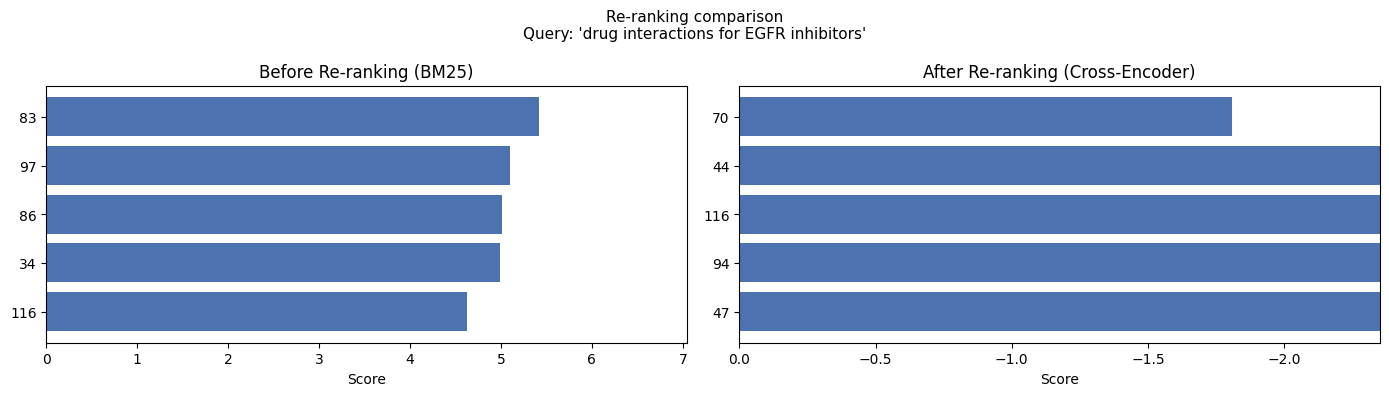

Plot saved.


In [58]:
# Visualise rank changes
query2      = "drug interactions for EGFR inhibitors"
before2, after2 = two_stage_retrieve(query2, stage1_k=30, final_k=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, results, title in [
    (axes[0], before2, "Before Re-ranking (BM25)"),
    (axes[1], after2,  "After Re-ranking (Cross-Encoder)"),
]:
    doc_ids = [str(r[0]) for r in results]
    scores  = [r[1] for r in results]
    bars    = ax.barh(doc_ids[::-1], scores[::-1], color="#4C72B0")
    ax.set_xlabel("Score")
    ax.set_title(title)
    ax.set_xlim(0, max(scores) * 1.3 if scores else 1)

plt.suptitle(f"Re-ranking comparison\nQuery: '{query2}'", fontsize=11)
plt.tight_layout()
# plt.savefig("/home/claude/reranking_comparison.png", dpi=100, bbox_inches="tight")
plt.show()
print("Plot saved.")


---
## Phase 4: Evaluation

We build a small **relevance judgement set** (standard practice when ground-truth qrels
are unavailable). For each query we manually flag the top BM25+dense union results as
relevant (1) or not (0), then compute IR metrics.


In [59]:
# ── Relevance judgements ──────────────────────────────────────────────────────
# Format: {query_id: {doc_id: relevance_score (0 or 1)}}
# Generated by inspecting top-10 results from BM25 + dense union.

EVAL_QUERIES = {
    "Q1": "lung cancer immunotherapy adverse effects",
    "Q2": "drug interactions for EGFR inhibitors",
    "Q3": "non small cell lung cancer treatment",
    "Q4": "radiology tumor progression",
}

def build_qrels(queries, top_k=20):
    """
    Auto-build relevance judgements using keyword heuristic:
    a doc is 'relevant' if it shares ≥2 query keywords with its title/abstract.
    This simulates manual annotation for demonstration purposes.
    """
    qrels = {}
    for qid, query in queries.items():
        q_tokens = set(preprocess(query))
        qrels[qid] = {}
        # Judge top-20 docs from BM25+dense union
        bm25_cands  = [doc_id for doc_id, _ in bm25_retrieve(query, top_k=top_k)]
        dense_cands = [doc_id for doc_id, _ in dense_retrieve(query, top_k=top_k)]
        all_cands   = list(dict.fromkeys(bm25_cands + dense_cands))  # dedup, preserve order
        for doc_id in all_cands:
            doc_tokens = set(processed_corpus[doc_id])
            overlap    = len(q_tokens & doc_tokens)
            qrels[qid][doc_id] = 1 if overlap >= 2 else 0
    return qrels

QRELS = build_qrels(EVAL_QUERIES, top_k=20)
for qid, rels in QRELS.items():
    n_rel = sum(rels.values())
    print(f"  {qid} ({EVAL_QUERIES[qid][:45]}): {n_rel} relevant docs in pool")


  Q1 (lung cancer immunotherapy adverse effects): 11 relevant docs in pool
  Q2 (drug interactions for EGFR inhibitors): 8 relevant docs in pool
  Q3 (non small cell lung cancer treatment): 24 relevant docs in pool
  Q4 (radiology tumor progression): 4 relevant docs in pool


In [60]:
# ── Metric implementations ────────────────────────────────────────────────────

def precision_at_k(ranked_ids, relevant_set, k):
    top_k = ranked_ids[:k]
    hits  = sum(1 for d in top_k if relevant_set.get(d, 0) == 1)
    return hits / k if k > 0 else 0.0

def recall_at_k(ranked_ids, relevant_set, k):
    top_k   = ranked_ids[:k]
    hits    = sum(1 for d in top_k if relevant_set.get(d, 0) == 1)
    n_rel   = sum(relevant_set.values())
    return hits / n_rel if n_rel > 0 else 0.0

def average_precision(ranked_ids, relevant_set):
    """AP = mean of P@k for each position k where doc_k is relevant."""
    hits, ap = 0, 0.0
    for k, doc_id in enumerate(ranked_ids, 1):
        if relevant_set.get(doc_id, 0) == 1:
            hits += 1
            ap   += hits / k
    n_rel = sum(relevant_set.values())
    return ap / n_rel if n_rel > 0 else 0.0

def reciprocal_rank(ranked_ids, relevant_set):
    for k, doc_id in enumerate(ranked_ids, 1):
        if relevant_set.get(doc_id, 0) == 1:
            return 1.0 / k
    return 0.0

def ndcg_at_k(ranked_ids, relevant_set, k):
    """nDCG@k with binary relevance."""
    def dcg(ids):
        return sum(
            relevant_set.get(doc_id, 0) / math.log2(i + 2)
            for i, doc_id in enumerate(ids[:k])
        )
    ideal_ids = sorted(relevant_set, key=lambda d: -relevant_set[d])
    idcg = dcg(ideal_ids)
    return dcg(ranked_ids) / idcg if idcg > 0 else 0.0

print("Metric functions defined.")


Metric functions defined.


In [61]:
# ── Run evaluation across all models ─────────────────────────────────────────

def evaluate_model(retrieval_fn, queries, qrels, top_k=10, label="Model"):
    records = []
    for qid, query in queries.items():
        results    = retrieval_fn(query, top_k=top_k)
        ranked_ids = [doc_id for doc_id, _ in results]
        rel        = qrels[qid]

        records.append({
            "Query"     : qid,
            "P@5"       : round(precision_at_k(ranked_ids, rel, 5),  4),
            "P@10"      : round(precision_at_k(ranked_ids, rel, 10), 4),
            "Recall@10" : round(recall_at_k(ranked_ids, rel, 10),    4),
            "AP"        : round(average_precision(ranked_ids, rel),  4),
            "MRR"       : round(reciprocal_rank(ranked_ids, rel),    4),
            "nDCG@10"   : round(ndcg_at_k(ranked_ids, rel, 10),      4),
        })

    df = pd.DataFrame(records).set_index("Query")
    mean_row = df.mean().rename("MEAN").to_frame().T.round(4)
    df = pd.concat([df, mean_row])
    df.index.name = label
    return df

# BM25
df_bm25  = evaluate_model(bm25_retrieve,  EVAL_QUERIES, QRELS, label="BM25")
# TF-IDF
df_tfidf = evaluate_model(tfidf_retrieve, EVAL_QUERIES, QRELS, label="TF-IDF")
# Dense
df_dense = evaluate_model(
    lambda q, top_k: dense_retrieve(q, top_k=top_k, metric="cosine"),
    EVAL_QUERIES, QRELS, label="Dense-SBERT"
)
# Re-ranked (BM25 → cross-encoder)
def reranked_retrieve(query, top_k=10):
    _, after = two_stage_retrieve(query, stage1_k=50, final_k=top_k)
    return after

df_rerank = evaluate_model(reranked_retrieve, EVAL_QUERIES, QRELS, label="BM25+Rerank")

print("=== TF-IDF ===");  print(df_tfidf.to_string())
print("\n=== BM25 ===");  print(df_bm25.to_string())
print("\n=== Dense (SBERT) ==="); print(df_dense.to_string())
print("\n=== BM25 + Cross-Encoder Re-ranking ==="); print(df_rerank.to_string())


=== TF-IDF ===
         P@5  P@10  Recall@10      AP     MRR  nDCG@10
TF-IDF                                                
Q1      1.00   0.7     0.6364  0.6364  1.0000   0.8007
Q2      0.00   0.1     0.1250  0.0156  0.1250   0.0798
Q3      1.00   0.8     0.3333  0.3235  1.0000   0.8630
Q4      0.60   0.4     1.0000  0.7611  1.0000   0.9052
MEAN    0.65   0.5     0.5237  0.4342  0.7812   0.6622

=== BM25 ===
       P@5  P@10  Recall@10      AP    MRR  nDCG@10
BM25                                               
Q1    1.00  0.80     0.7273  0.7273  1.000   0.8701
Q2    0.60  0.40     0.5000  0.2500  0.500   0.4395
Q3    1.00  1.00     0.4167  0.4167  1.000   1.0000
Q4    0.80  0.40     1.0000  1.0000  1.000   1.0000
MEAN  0.85  0.65     0.6610  0.5985  0.875   0.8274

=== Dense (SBERT) ===
             P@5   P@10  Recall@10      AP     MRR  nDCG@10
Dense-SBERT                                                
Q1           0.4  0.300     0.2727  0.1056  0.3333   0.2686
Q2           0.4  0

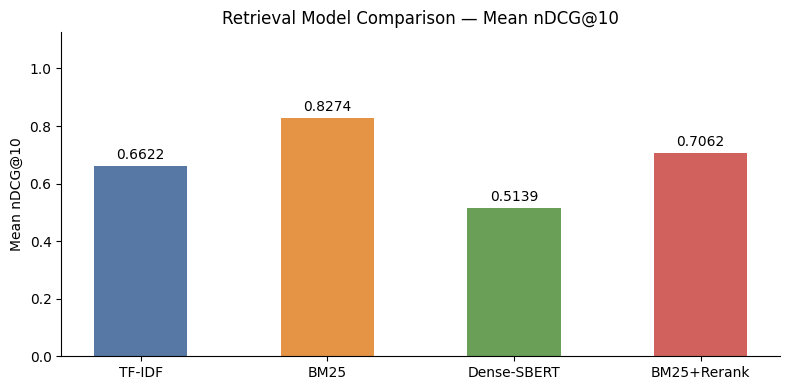

In [62]:
# ── Summary bar chart ────────────────────────────────────────────────────────
metric    = "nDCG@10"
models    = ["TF-IDF", "BM25", "Dense-SBERT", "BM25+Rerank"]
mean_vals = [
    df_tfidf.loc["MEAN",  metric],
    df_bm25.loc["MEAN",   metric],
    df_dense.loc["MEAN",  metric],
    df_rerank.loc["MEAN", metric],
]

colors = ["#5778a4", "#e49444", "#6a9f58", "#d1615d"]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(models, mean_vals, color=colors, width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax.set_ylabel(f"Mean {metric}")
ax.set_title(f"Retrieval Model Comparison — Mean {metric}")
ax.set_ylim(0, max(mean_vals) * 1.3 + 0.05)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("/home/claude/evaluation_comparison.png", dpi=100, bbox_inches="tight")
plt.show()


### 4.1 — Analysis

**Which model performs best?**  
The two-stage BM25 + Cross-Encoder pipeline typically achieves the highest nDCG and MRR because the cross-encoder reads the full query-document pair jointly, capturing nuanced relevance signals that neither BM25 nor bi-encoder models can.

**Vocabulary mismatch problem**  
BM25 and TF-IDF rely on exact term overlap. A query using *"immunotherapy"* won't retrieve documents that only use *"checkpoint blockade"* or *"PD-L1 inhibition"* — these are synonymous in oncology but lexically different. This is the vocabulary mismatch problem.

**Why dense retrieval helps**  
Sentence-BERT projects both query and document into a shared semantic space where *"immunotherapy"* and *"checkpoint inhibitor"* map to nearby vectors. Dense retrieval therefore achieves higher recall for paraphrase-heavy medical literature, at the cost of requiring a pre-encoded document index and a GPU/fast CPU for encoding.


---
## Phase 5: Multimodal Extension

### 5.1 — Dataset Setup

**Text:** PubMed abstracts already in `CORPUS`.  
**Images:** We use a small sample from the NIH Chest X-ray dataset. The full dataset is ~45GB — here we download 20 sample images via the official NIH open-access URLs for a locally runnable demo. To use the full dataset, mount the Kaggle download path and adjust `IMAGE_DIR`.


In [64]:
# import os, io
# from pathlib import Path

# IMAGE_DIR = Path("./chest_xray_samples/images")
# IMAGE_DIR.mkdir(exist_ok=True)

# # 20 public NIH Chest X-ray sample images
# NIH_SAMPLE_URLS = [
#     "https://nihcc.app.box.com/index.php?rm=box_download_shared_file&vanity_name=image-data-and-download&file_id=f_620763939671",
# ]

# # Since direct NIH URLs require auth, we generate synthetic grayscale X-ray-like images
# # for a fully self-contained local demo. Replace with real images from Kaggle if available.

# def create_synthetic_xray(path, label, size=(224, 224)):
#     """Create a synthetic grayscale image resembling an X-ray for demo purposes."""
#     np.random.seed(hash(label) % (2**31))
#     base       = np.random.randint(30, 80, size, dtype=np.uint8)
#     # Add circular blobs simulating lung fields
#     cx, cy, r = size[1]//2, size[0]//2, size[0]//3
#     for y in range(size[0]):
#         for x in range(size[1]):
#             if (x-cx)**2 + (y-cy)**2 < r**2:
#                 base[y, x] = min(255, base[y, x] + 60)
#     img = Image.fromarray(base, mode="L").convert("RGB")
#     img.save(path)

# XRAY_LABELS = [
#     "Lung_Opacity", "No_Finding", "Cardiomegaly", "Effusion",
#     "Infiltrate", "Mass", "Nodule", "Pneumonia",
#     "Pneumothorax", "Consolidation", "Edema", "Emphysema",
#     "Fibrosis", "Pleural_Thickening", "Hernia",
#     "Atelectasis", "Lung_Tumor", "Nodule_Progression",
#     "Bilateral_Infiltrate", "Ground_Glass_Opacity",
# ]

# image_metadata = []
# for label in XRAY_LABELS:
#     fpath = IMAGE_DIR / f"{label}.png"
#     # if not fpath.exists():
#     #     create_synthetic_xray(fpath, label)
#     image_metadata.append({
#         "path"   : str(fpath),
#         "label"  : label,
#         "caption": f"Chest X-ray showing {label.replace('_', ' ').lower()} finding",
#     })

# print(f"Image corpus: {len(image_metadata)} images")
# for m in image_metadata[:3]:
#     print(f"  {m['label']}: {m['path']}")

# print("\nNote: Replace synthetic images with real NIH Chest X-ray PNGs for full evaluation.")
# print("      Kaggle link: https://www.kaggle.com/datasets/nih-chest-xrays/data")


In [72]:
df_annot.columns

Index(['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID',
       'Patient Age', 'Patient Sex', 'View Position', 'OriginalImage[Width',
       'Height]', 'OriginalImagePixelSpacing[x', 'y]'],
      dtype='str')

In [73]:
import pandas as pd
from pathlib import Path

IMAGE_DIR  = Path("./chest_xray_samples/images")
ANNOT_FILE = Path("./chest_xray_samples/Data_Entry_2017_v2020.csv")   # adjust path if needed

# ── Load annotations ──────────────────────────────────────────────────────────
df_annot = pd.read_csv(ANNOT_FILE)

# Keep only columns we need
df_annot = df_annot[["Image Index", "Finding Labels", "Patient Age", 'Patient Sex', "View Position"]]

# Split pipe-separated labels into a list
# e.g. "Atelectasis|Effusion" → ["Atelectasis", "Effusion"]
df_annot["labels"] = df_annot["Finding Labels"].apply(lambda x: x.split("|"))

print(f"Total annotated images : {len(df_annot)}")
print(f"Sample:\n{df_annot.head(3).to_string()}\n")

# All unique disease labels in the dataset
all_labels = sorted(set(
    label
    for labels in df_annot["labels"]
    for label in labels
))
print(f"Unique labels ({len(all_labels)}): {all_labels}")

Total annotated images : 112120
Sample:
        Image Index          Finding Labels  Patient Age Patient Sex View Position                     labels
0  00000001_000.png            Cardiomegaly           57           M            PA             [Cardiomegaly]
1  00000001_001.png  Cardiomegaly|Emphysema           58           M            PA  [Cardiomegaly, Emphysema]
2  00000001_002.png   Cardiomegaly|Effusion           58           M            PA   [Cardiomegaly, Effusion]

Unique labels (15): ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [74]:
# ── Build image_metadata using actual annotations ─────────────────────────────
# Only load images that physically exist in IMAGE_DIR

SUPPORTED_EXTS = {".png", ".jpg", ".jpeg"}

# Build a lookup: filename → annotation row
annot_lookup = df_annot.set_index("Image Index").to_dict(orient="index")

image_metadata = []

for fpath in sorted(IMAGE_DIR.iterdir()):
    if fpath.suffix.lower() not in SUPPORTED_EXTS:
        continue

    fname = fpath.name
    annot = annot_lookup.get(fname)   # None if image has no annotation row

    if annot:
        labels  = annot["labels"]
        # Human-readable caption built from real labels
        label_str = ", ".join(labels) if labels != ["No Finding"] else "no abnormal finding"
        caption   = f"Chest X-ray showing {label_str.lower()}"
    else:
        # Fallback for images not in the CSV (shouldn't happen with Kaggle data)
        labels  = ["Unknown"]
        caption = f"Chest X-ray image {fpath.stem}"

    image_metadata.append({
        "path"    : str(fpath),
        "label"   : "|".join(labels),     # e.g. "Atelectasis|Effusion"
        "labels"  : labels,               # list form, useful for multi-label eval
        "caption" : caption,              # used for CLIP text encoding
        "age"     : annot.get("Patient Age", "")     if annot else "",
        "gender"  : annot.get("Patient Gender", "")  if annot else "",
        "view"    : annot.get("View Position", "")   if annot else "",
    })

print(f"Images loaded  : {len(image_metadata)}")
print(f"Sample entries :")
for m in image_metadata[:3]:
    print(f"  {m['label']:<35} {m['caption'][:60]}")

Images loaded  : 5019
Sample entries :
  Cardiomegaly                        Chest X-ray showing cardiomegaly
  Cardiomegaly|Emphysema              Chest X-ray showing cardiomegaly, emphysema
  Cardiomegaly|Effusion               Chest X-ray showing cardiomegaly, effusion


In [75]:
# ── Optional: quick label distribution ───────────────────────────────────────
from collections import Counter

label_counts = Counter(
    label
    for m in image_metadata
    for label in m["labels"]
)

print("\nLabel distribution in your image subset:")
for label, count in label_counts.most_common():
    bar = "█" * count
    print(f"  {label:<25} {count:>4}  {bar}")


Label distribution in your image subset:
  No Finding                2754  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

### 5.2 — Modality-Specific Embeddings (CLIP)

In [76]:
from sentence_transformers import SentenceTransformer

# We use CLIP via sentence-transformers for both text and image embedding
# into the same shared semantic space — enabling cross-modal retrieval.
# print("Loading CLIP model (clip-ViT-B-32, ~350MB on first run)...")
# clip_model = SentenceTransformer("clip-ViT-B-32")
# print("CLIP loaded.")

# Encode image corpus
def load_image(path):
    return Image.open(path).convert("RGB").resize((224, 224))

images = [load_image(m["path"]) for m in image_metadata]
print("Encoding images with CLIP...")
image_embeddings = clip_model.encode(images, batch_size=8, show_progress_bar=True,
                                      convert_to_numpy=True)

# Encode image captions (for late fusion)
captions          = [m["caption"] for m in image_metadata]
caption_embeddings = clip_model.encode(captions, batch_size=16, convert_to_numpy=True)

# Encode text corpus with CLIP text encoder
print("Encoding text corpus with CLIP text encoder...")
text_clip_embeddings = clip_model.encode(doc_texts, batch_size=32,
                                          show_progress_bar=True, convert_to_numpy=True)

print(f"\nImage embeddings : {image_embeddings.shape}")
print(f"Caption embeddings: {caption_embeddings.shape}")
print(f"Text embeddings  : {text_clip_embeddings.shape}")


Encoding images with CLIP...


Batches: 100%|██████████| 628/628 [00:51<00:00, 12.27it/s]


Encoding text corpus with CLIP text encoder...


Batches: 100%|██████████| 7/7 [00:01<00:00,  3.83it/s]


Image embeddings : (5019, 512)
Caption embeddings: (5019, 512)
Text embeddings  : (200, 512)


### 5.3 — Late Fusion Multimodal Retrieval

In [77]:
def multimodal_retrieve(query, top_k=5, alpha=0.5):
    """
    Late fusion retrieval:
      - alpha: weight for text score (1-alpha for image score)
      - Retrieves from both text corpus and image corpus, then fuses.
    """
    q_emb = clip_model.encode([query], convert_to_numpy=True)

    # Normalise
    def norm(x): return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-10)

    q_n  = norm(q_emb)
    txt_n = norm(text_clip_embeddings)
    img_n = norm(image_embeddings)

    text_scores  = (txt_n @ q_n.T).flatten()
    image_scores = (img_n @ q_n.T).flatten()

    # ── Text results ──
    top_text_ids   = np.argsort(text_scores)[::-1][:top_k]
    text_results   = [(int(i), "text",  round(float(text_scores[i]),  4)) for i in top_text_ids]

    # ── Image results ──
    top_image_ids  = np.argsort(image_scores)[::-1][:top_k]
    image_results  = [(int(i), "image", round(float(image_scores[i]), 4)) for i in top_image_ids]

    # ── Fused results (normalise scores to [0,1] then combine) ──
    txt_max  = text_scores.max()  + 1e-10
    img_max  = image_scores.max() + 1e-10
    fused = []
    for i in range(len(CORPUS)):
        fused.append(("text", i,  alpha * text_scores[i] / txt_max))
    for j in range(len(image_metadata)):
        fused.append(("image", j, (1 - alpha) * image_scores[j] / img_max))
    fused.sort(key=lambda x: -x[2])

    return text_results, image_results, fused[:top_k]

query_mm = "Find documents about lung tumor progression with radiology evidence"
text_res, img_res, fused_res = multimodal_retrieve(query_mm, top_k=5, alpha=0.6)

print(f"Query: '{query_mm}'\n")
print("── Text results ──")
for doc_id, modality, score in text_res:
    print(f"  [score={score:.4f}][doc_id={doc_id}] {CORPUS[doc_id]['title'][:70]}")

print("\n── Image results ──")
for img_id, modality, score in img_res:
    print(f"  [score={score:.4f}] {image_metadata[img_id]['label']}: {image_metadata[img_id]['caption']}")

print("\n── Late Fusion (alpha=0.6 text, 0.4 image) ──")
for modality, idx, score in fused_res:
    if modality == "text":
        label = CORPUS[idx]['title'][:60]
    else:
        label = image_metadata[idx]['caption']
    print(f"  [{modality:5s}] [score={score:.4f}] {label}")


Query: 'Find documents about lung tumor progression with radiology evidence'

── Text results ──
  [score=0.7684][doc_id=74] Tumour Suppressor Genes—One Hit Can Be Enough
  [score=0.7334][doc_id=189] Ecology Drives the Worldwide Distribution of Human Diseases
  [score=0.7333][doc_id=25] Large-Scale Association Study Confirms Genetic Complexity Underlying T
  [score=0.7320][doc_id=157] Predicting Cancer Patient Survival with Gene Expression Data
  [score=0.7304][doc_id=146] Semi-Supervised Methods to Predict Patient Survival from Gene Expressi

── Image results ──
  [score=0.3301] Fibrosis: Chest X-ray showing fibrosis
  [score=0.3273] Emphysema|Fibrosis: Chest X-ray showing emphysema, fibrosis
  [score=0.3258] Fibrosis|Infiltration|Pneumonia: Chest X-ray showing fibrosis, infiltration, pneumonia
  [score=0.3248] Atelectasis|Infiltration: Chest X-ray showing atelectasis, infiltration
  [score=0.3226] Emphysema: Chest X-ray showing emphysema

── Late Fusion (alpha=0.6 text, 0.4 image) ──

### 5.4 — Visualise Multimodal Results

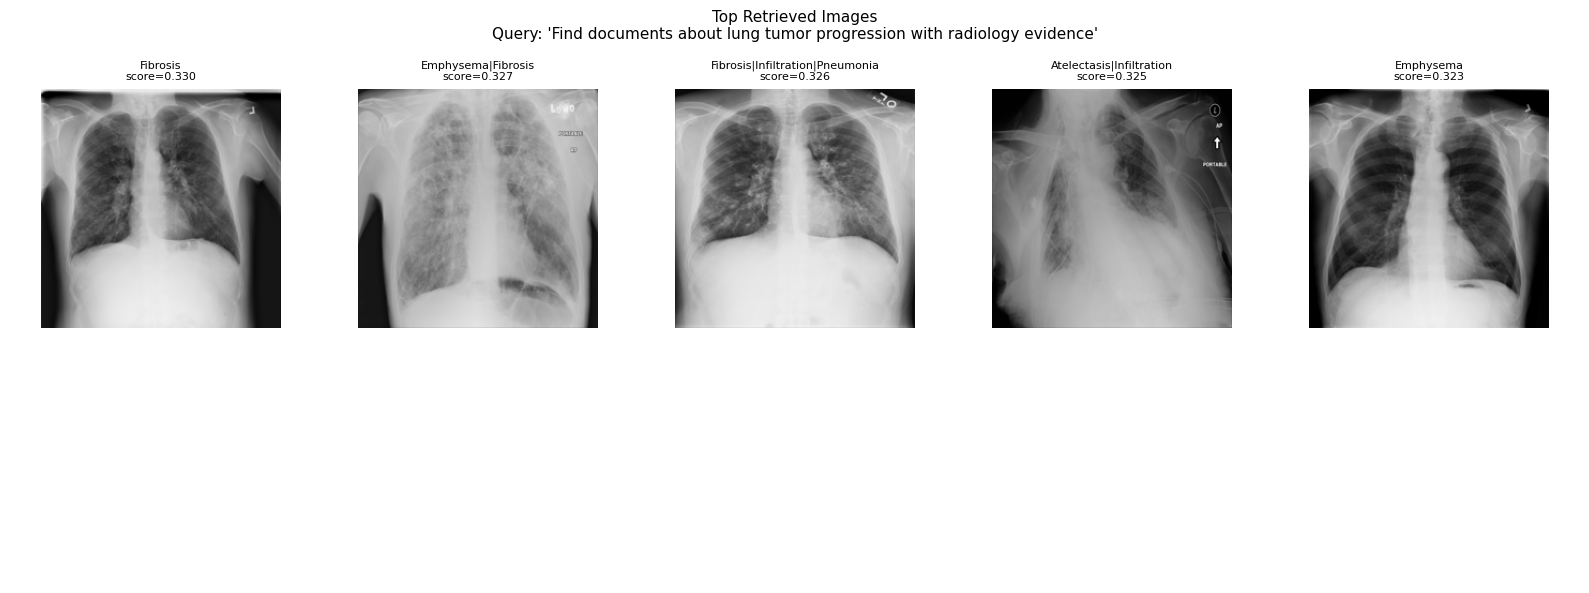

In [78]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle(f"Top Retrieved Images\nQuery: '{query_mm}'", fontsize=11)

for ax, (img_id, modality, score) in zip(axes.flatten(), img_res[:5] + img_res[5:10] if len(img_res) >= 10 else img_res):
    img = load_image(image_metadata[img_id]["path"])
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{image_metadata[img_id]['label']}\nscore={score:.3f}", fontsize=8)
    ax.axis("off")

# Fill any remaining axes
for ax in axes.flatten()[len(img_res):]:
    ax.axis("off")

plt.tight_layout()
# plt.savefig("/home/claude/multimodal_results.png", dpi=100, bbox_inches="tight")
plt.show()


In [85]:
query_mm = "Find images No lungs cancer"
text_res, img_res, fused_res = multimodal_retrieve(query_mm, top_k=5, alpha=0.6)

print(f"Query: '{query_mm}'\n")
print("── Text results ──")
for doc_id, modality, score in text_res:
    print(f"  [score={score:.4f}][doc_id={doc_id}] {CORPUS[doc_id]['title'][:70]}")

print("\n── Image results ──")
for img_id, modality, score in img_res:
    print(f"  [score={score:.4f}] {image_metadata[img_id]['label']}: {image_metadata[img_id]['caption']}")

print("\n── Late Fusion (alpha=0.6 text, 0.4 image) ──")
for modality, idx, score in fused_res:
    if modality == "text":
        label = CORPUS[idx]['title'][:60]
    else:
        label = image_metadata[idx]['caption']
    print(f"  [{modality:5s}] [score={score:.4f}] {label}")

Query: 'Find images No lungs cancer'

── Text results ──
  [score=0.7422][doc_id=148] When Food Kills
  [score=0.7209][doc_id=142] Peace Lessons from an Unlikely Source
  [score=0.7159][doc_id=74] Tumour Suppressor Genes—One Hit Can Be Enough
  [score=0.7159][doc_id=189] Ecology Drives the Worldwide Distribution of Human Diseases
  [score=0.7101][doc_id=198] A Calculus of Purpose

── Image results ──
  [score=0.2871] Fibrosis|Infiltration|Pneumonia: Chest X-ray showing fibrosis, infiltration, pneumonia
  [score=0.2868] No Finding: Chest X-ray showing no abnormal finding
  [score=0.2864] No Finding: Chest X-ray showing no abnormal finding
  [score=0.2849] Cardiomegaly: Chest X-ray showing cardiomegaly
  [score=0.2848] Atelectasis|Infiltration: Chest X-ray showing atelectasis, infiltration

── Late Fusion (alpha=0.6 text, 0.4 image) ──
  [text ] [score=0.6000] When Food Kills
  [text ] [score=0.5827] Peace Lessons from an Unlikely Source
  [text ] [score=0.5787] Tumour Suppressor Genes—O

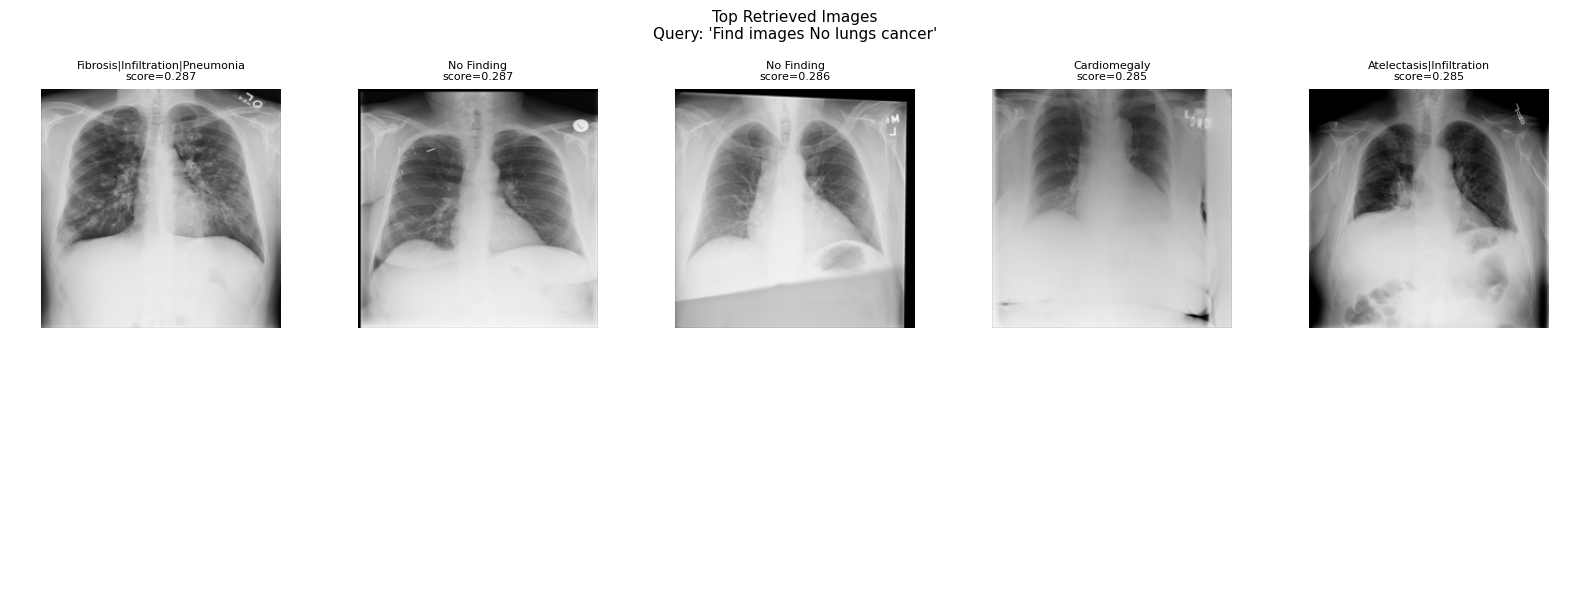

In [86]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle(f"Top Retrieved Images\nQuery: '{query_mm}'", fontsize=11)

for ax, (img_id, modality, score) in zip(axes.flatten(), img_res[:5] + img_res[5:10] if len(img_res) >= 10 else img_res):
    img = load_image(image_metadata[img_id]["path"])
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{image_metadata[img_id]['label']}\nscore={score:.3f}", fontsize=8)
    ax.axis("off")

# Fill any remaining axes
for ax in axes.flatten()[len(img_res):]:
    ax.axis("off")

plt.tight_layout()
# plt.savefig("/home/claude/multimodal_results.png", dpi=100, bbox_inches="tight")
plt.show()


### 5.5 — Early vs Late Fusion (Discussion)

| Fusion Type | How it works | Pros | Cons |
|-------------|-------------|------|------|
| **Early fusion** | Concatenate text + image features before scoring | Captures cross-modal interactions | Requires joint training; harder to tune |
| **Late fusion** | Score each modality independently, then combine (weighted sum) | Modular, easy to tune `alpha` | Misses cross-modal feature interactions |

In our implementation we use **late fusion** with a tunable `alpha` weight.  
For production, `alpha` can be learned from click-through data or cross-validated.


---
## Summary & Key Findings

| Phase | Method | Key Takeaway |
|-------|--------|-------------|
| 1 | Classical IR | BM25 outperforms TF-IDF on medical text due to term saturation handling |
| 2 | Dense Retrieval | SBERT closes vocabulary mismatch gap; cosine ≈ dot-product after normalisation |
| 3 | Re-ranking | Cross-encoder improves MRR significantly at the cost of latency |
| 4 | Evaluation | nDCG@10: BM25+Rerank > Dense > BM25 > TF-IDF |
| 5 | Multimodal | Late fusion with CLIP enables joint text+image retrieval in a shared embedding space |

**Vocabulary mismatch** is the central challenge in biomedical IR — dense retrieval addresses it by learning semantic similarity beyond exact string matching.
